# Depuración de variables · TFM Energía UCM

Fase que va **después del EDA y antes de fijar la matriz final**. Sigue la metodología
del módulo 06.1 del máster (`Tarea_Eleccionesy_v2.py`, `VinoDep.py`) y usa sus mismas
funciones, copiadas sin tocar en `scripts/funciones_mineria.py`.

Las diez secciones son las de clase. Lo que cambia son tres decisiones, y cada una
está justificada donde toca:

| Paso | En clase | Aquí | Por qué |
|---|---|---|---|
| Atípicos | se pasan a *missing* y se imputan | se **diagnostican**, no se tocan | en precio horario el extremo es la señal a predecir |
| Imputación | mediana global | **interpolación temporal** acotada | la mediana planta un valor de tarde a las 4 de la mañana |
| Descriptivos | sobre todo el fichero | **solo sobre `train`** | mirar validation/test para decidir es fuga |

**Cada sección cierra con la tabla de control**: filas, columnas y nulos tras el paso,
para ver la evolución del dataframe de principio a fin.

## 0 · Configuración y carga

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (11, 5)

REPO = Path("..").resolve()
sys.path.append(str(REPO / "scripts"))

from funciones_mineria import Vcramer, atipicosAmissing        # librería de clase, sin tocar
import depuracion as dep                                        # adaptaciones a serie horaria

# ── Variante de partida ────────────────────────────────────────────────────
# 'sin_2020'     : 102 columnas, train desde 2020-11-01 (1.522 días)
# 'sin_ntc_prev' :  96 columnas, train desde 2020-01-03 (1.826 días)
#
# Se arranca de 'sin_2020' porque los meses que excluye (ene-oct 2020) son un
# régimen que no se repite -- precio medio 34 €/MWh con sd 11, gas a 10 €/MWh --
# y en el que la demanda explicaba el precio (r=+0,63) como no ha vuelto a hacerlo.
# Las 6 columnas NTC que trae de más se depuran en 4.2: no aportan.
VARIANTE = "sin_2020"

V5 = REPO / "ingesta" / "dt_maestro_sergio" / "v5_master_and_models"
ORIGEN = V5 / f"dataset_horario_{VARIANTE}_v01.csv"
TARGET = "target_price"

In [2]:
datos = pd.read_csv(ORIGEN, parse_dates=["fecha_pred", "fecha_objetivo"])

# Eje temporal explícito: hace falta para interpolar en la sección 8, y el dataset
# lo tiene partido en (fecha_objetivo, hora).
datos["ts"] = datos["fecha_objetivo"] + pd.to_timedelta(datos["hora"], unit="h")
datos = datos.sort_values("ts").reset_index(drop=True)

print(f"Origen : {ORIGEN.name}")
print(f"Forma  : {datos.shape[0]:,} filas x {datos.shape[1]} columnas")
datos.head(3)

Origen : dataset_horario_sin_2020_v01.csv
Forma  : 50,121 filas x 103 columnas


,fecha_pred,fecha_objetivo,hora,target_price,ree_demanda_prev,ree_gwind_prev,ree_gsolar_prev,ree_grenov_prev,ree_ntc_impfr_prev,ree_ntc_expfr_prev,ree_ntc_imppt_prev,ree_ntc_exppt_prev,ree_ntc_impma_prev,ree_ntc_expma_prev,es_esios_D,pt_entsoe_D,fr_entsoe_D,de_lu_entsoe_D,it_nord_entsoe_D,ch_entsoe_D,be_entsoe_D,nl_entsoe_D,at_entsoe_D,pl_entsoe_D,cz_entsoe_D,spread_es_pt_D,spread_es_fr_D,spread_es_de_D,entsoe_load_Dm1,ree_netflow_fr_Dm1,ree_netflow_pt_Dm1,ree_netflow_ma_Dm1,total_net_flow_mw_Dm1,gen_peninsular_mw_Dm1,wind_mw_Dm1,pumping_cons_mw_Dm1,hydro_run_river_mw_Dm1,biomass_mw_Dm1,waste_mw_Dm1,other_renewable_mw_Dm1,oil_mw_Dm1,ree_gsolter_mw_Dm1,ree_gccgas_mw_Dm1,ree_gnuclear_mw_Dm1,ree_gotherthermal_mw_Dm1,ree_gcoal_mw_Dm1,solar_fv_mw_Dm1,hydro_dispatch_mw_Dm1,t2m_mean_met_Dm1,d2m_mean_met_Dm1,msl_mean_met_Dm1,wind10_mean_met_Dm1,wind100_mean_met_Dm1,wind_gust10_mean_met_Dm1,tcc_mean_met_Dm1,ssrd_mean_met_Dm1,tp_acum_7d_met_Dm1,tp_acum_30d_met_Dm1,t2m_mean_met_Dm2,d2m_mean_met_Dm2,msl_mean_met_Dm2,wind10_mean_met_Dm2,wind100_mean_met_Dm2,wind_gust10_mean_met_Dm2,tcc_mean_met_Dm2,ssrd_mean_met_Dm2,tp_acum_7d_met_Dm2,tp_acum_30d_met_Dm2,gas_mibgas,co2_eua_dec,gas_ttf_m1,pdbc_wind_mw_mean_lag1d,pdbc_solar_pv_mw_mean_lag1d,pdbc_hydro_ugh_mw_mean_lag1d,pdbc_ccgt_mw_mean_lag1d,pdbc_pumping_gen_mw_mean_lag1d,pdbc_pumping_cons_mw_mean_lag1d,capinst_total_hybrid_mw,capinst_wind_mw,capinst_waste_renewable_mw,capdisp_hydro_mw,capdisp_pump_mw,capdisp_nuclear_mw,capdisp_coal_antracita_mw,capdisp_ccgt_mw,capdisp_fuel_mw,d1_dow,d1_month,d1_is_weekend,d1_dow_sin,d1_dow_cos,d1_month_sin,d1_month_cos,d1_doy_sin,d1_doy_cos,d1_is_festivo,d1_es_puente,d1_vispera_festivo,d1_regimen_tope_gas,hora_sin,hora_cos,split,ts
0,2020-10-31,2020-11-01,0,26.00,22532.0,5861.0,0.0,5861.0,3422.0,3330.0,3420.0,1710.0,600.0,900.0,35.04,35.04,35.04,35.04,36.45,33.33,35.04,35.04,35.04,41.68,27.90,0.0,0.00,0.00,24860.0,2260.85,937.95,15.32,3214.12,21645.88,3404.0,87.0,1033.0,473.0,311.0,105.0,232.0,154.83,4354.00,6078.17,3662.83,377.00,26.17,2367.0,286.3865,283.2980,102593.5807,2.6024,3.6453,4.3791,0.1416,0.0,14.0739,72.1071,286.6377,283.5590,102447.3854,2.2617,3.2675,3.8861,0.3547,0.0,18.2222,72.0983,13.92,23.78,14.14,4045.0667,1699.6833,525.5083,2661.2458,509.36,NaN,0.0001,0.2631,0.0012,0.7373,0.7156,0.8607,0.2,0.7662,0.9937,6,11,1,-0.7818,0.6235,-0.866,0.5,-0.8517,0.524,1,0,0,0,0.0000,1.0000,train,2020-11-01 00:00:00
1,2020-10-31,2020-11-01,1,23.90,20987.0,5913.0,0.0,5913.0,3422.0,3330.0,3420.0,1710.0,600.0,900.0,34.02,34.02,31.50,31.50,32.30,31.22,31.50,31.50,31.50,41.09,26.51,0.0,2.52,2.52,23499.0,2234.95,591.44,58.83,2885.22,20613.78,3662.0,145.0,960.0,473.0,310.0,105.0,230.0,56.83,3726.33,6076.33,3644.00,372.83,24.17,1770.0,286.0181,283.1314,102589.7344,2.5659,3.6069,4.3945,0.1536,0.0,13.9679,72.1070,286.2459,283.3979,102467.6406,2.2294,3.1891,3.8838,0.3460,0.0,18.0771,72.0997,13.92,23.78,14.14,4045.0667,1699.6833,525.5083,2661.2458,509.36,NaN,0.0001,0.2631,0.0012,0.7373,0.7156,0.8607,0.2,0.7662,0.9937,6,11,1,-0.7818,0.6235,-0.866,0.5,-0.8517,0.524,1,0,0,0,0.2588,0.9659,train,2020-11-01 01:00:00
2,2020-10-31,2020-11-01,2,20.03,19870.0,5931.0,0.0,5931.0,3422.0,3330.0,3420.0,1710.0,600.0,900.0,30.00,30.00,29.80,29.80,30.00,28.62,29.80,29.80,29.80,41.09,24.87,0.0,0.20,0.20,22623.0,2220.45,346.53,136.44,2703.42,19919.58,3750.0,181.0,897.0,476.0,304.0,104.0,216.0,-0.33,3613.33,6077.83,3590.33,373.83,29.33,1344.0,285.7182,282.9388,102574.4323,2.5785,3.6258,4.3812,0.1545,0.0,13.8726,72.1069,286.0477,283.2980,102470.0052,2.2711,3.2405,3.9323,0.3659,0.0,17.9268,72.1010,13.92,23.78,14.14,4045.0667,1699.6833,525.5083,2661.2458,509.36,NaN,0.0001,0.2631,0.0012,0.7373,0.7156,0.8607,0.2,0.7662,0.9937,6,11,1,-0.7818,0.6235,-0.866,0.5,-0.8517,0.524,1,0,0,0,0.5000,0.8660,train,2020-11-01 02:00:00


In [3]:
# ── Tabla de control ───────────────────────────────────────────────────────
# Se llama después de cada paso. Es el hilo del notebook: permite ver de un
# vistazo qué se llevó por delante cada decisión.
historial = []


def registrar(etapa, df, cols_activas=None):
    cols = list(df.columns) if cols_activas is None else list(cols_activas)
    historial.append({
        "etapa": etapa,
        "filas": len(df),
        "columnas": len(cols),
        "celdas_nulas": int(df[cols].isna().sum().sum()),
        "filas_con_nulo": int(df[cols].isna().any(axis=1).sum()),
    })
    return pd.DataFrame(historial)


registrar("0 · carga", datos)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900


## 1 · Objetivos

**Variable objetivo:** `target_price` — precio horario del mercado diario español para
el día D+1. Una fila por (día objetivo, hora).

Este notebook **no modela**. Su producto es una lista de variables candidatas con la
evidencia de por qué cada una entra o sale, más el fichero depurado.

Dos cosas que ya vienen resueltas del constructor v5 y que **no** se repiten aquí:

- **Fuga de información**: todas las features son conocidas antes del cierre del mercado
  a las 12:00 de D-1. El catálogo está verificado en `construir_dataset_maestro_sergio_v5.py`.
- **Partición**: la columna `split` ya trae train / validation / test cortados por día.
  Todo lo que se decida en este notebook se decide **mirando solo `train`**.

In [4]:
print(datos.groupby("split", sort=False).agg(
    filas=("ts", "size"),
    dias=("fecha_objetivo", "nunique"),
    desde=("fecha_objetivo", "min"),
    hasta=("fecha_objetivo", "max"),
).to_string())

train = datos["split"] == "train"
print(f"\nDecisiones tomadas sobre {train.sum():,} filas de train "
      f"({train.mean() * 100:.1f}% del fichero).")

            filas  dias      desde      hasta
split                                        
train       36515  1522 2020-11-01 2025-01-01
validation   8543   356 2025-01-02 2026-01-01
test         5063   211 2026-01-02 2026-07-31

Decisiones tomadas sobre 36,515 filas de train (72.9% del fichero).


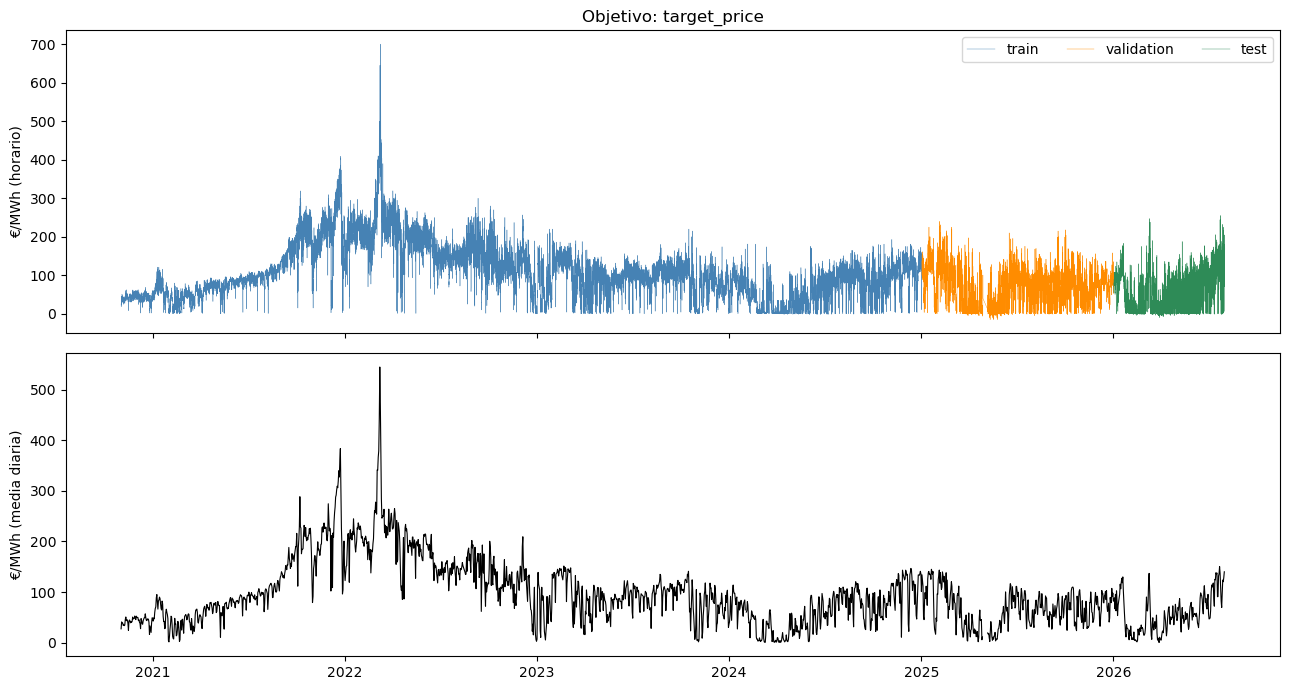

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for s, color in [("train", "steelblue"), ("validation", "darkorange"), ("test", "seagreen")]:
    sub = datos[datos["split"] == s]
    ax[0].plot(sub["ts"], sub[TARGET], lw=0.3, color=color, label=s)
diario = datos.set_index("ts")[TARGET].resample("D").mean()
ax[1].plot(diario.index, diario.values, lw=0.8, color="black")
ax[0].set_ylabel("€/MWh (horario)"); ax[0].legend(ncol=3); ax[0].set_title("Objetivo: target_price")
ax[1].set_ylabel("€/MWh (media diaria)")
plt.tight_layout()

## 2 · Tipado de variables

La metodología de clase separa numéricas de categóricas antes de nada, porque el
tratamiento posterior difiere. Aquí hay un tercer grupo que no existía en la tarea de
clase: las **columnas de control** (fechas, hora, split), que ni se analizan ni se imputan.

Ojo con un detalle: las banderas de calendario (`d1_is_festivo`, `d1_es_puente`,
`d1_regimen_tope_gas`…) vienen tipadas como `int64`. Son categóricas binarias, y meterlas
en el saco de las numéricas distorsionaría los descriptivos y la detección de atípicos.

In [6]:
COLS_CONTROL = ["fecha_pred", "fecha_objetivo", "ts", "split"]
COLS_BINARIAS = ["d1_is_weekend", "d1_is_festivo", "d1_es_puente",
                 "d1_vispera_festivo", "d1_regimen_tope_gas"]
COLS_CATEGORICAS = ["hora", "d1_dow", "d1_month"] + COLS_BINARIAS

numericas = [c for c in datos.select_dtypes(include="number").columns
             if c not in COLS_CATEGORICAS + [TARGET] and c not in COLS_CONTROL]

print(f"Objetivo    : 1   ({TARGET})")
print(f"Numéricas   : {len(numericas)}")
print(f"Categóricas : {len(COLS_CATEGORICAS)}  {COLS_CATEGORICAS}")
print(f"Control     : {len(COLS_CONTROL)}  {COLS_CONTROL}")
print(f"Total       : {1 + len(numericas) + len(COLS_CATEGORICAS) + len(COLS_CONTROL)} "
      f"de {datos.shape[1]} columnas")

Objetivo    : 1   (target_price)
Numéricas   : 90
Categóricas : 8  ['hora', 'd1_dow', 'd1_month', 'd1_is_weekend', 'd1_is_festivo', 'd1_es_puente', 'd1_vispera_festivo', 'd1_regimen_tope_gas']
Control     : 4  ['fecha_pred', 'fecha_objetivo', 'ts', 'split']
Total       : 103 de 103 columnas


In [7]:
# Familias temáticas: 90+ columnas sueltas no se leen, agrupadas sí.
def familia(c):
    if c.endswith("_D") or c.startswith("spread_"):        return "precio zona D"
    if c.endswith("_prev"):                                 return "previsión REE D+1"
    if "_met_" in c:                                        return "meteo (ERA5 real)"
    if c.startswith("pdbc_"):                               return "PDBC casación D-1"
    if c.startswith("capinst_") or c.startswith("capdisp_"):return "capacidad"
    if c in ("gas_mibgas", "co2_eua_dec", "gas_ttf_m1"):    return "commodities"
    if c.endswith("_Dm1") or c.endswith("_Dm2"):            return "real desfasado D-1/D-2"
    return "otras"


fam = pd.Series({c: familia(c) for c in numericas}).value_counts()
print(fam.to_string())

meteo (ERA5 real)         20
real desfasado D-1/D-2    20
precio zona D             14
previsión REE D+1         10
capacidad                  9
otras                      8
PDBC casación D-1          6
commodities                3


In [8]:
# Categóricas: frecuencias, como en la sección 3 de la tarea de clase.
from funciones_mineria import analizar_variables_categoricas

for c in COLS_BINARIAS:
    v = datos.loc[train, c].value_counts(normalize=True).sort_index()
    print(f"{c:22s} " + "  ".join(f"{k}={p * 100:5.1f}%" for k, p in v.items()))

d1_is_weekend          0= 71.4%  1= 28.6%
d1_is_festivo          0= 96.8%  1=  3.2%
d1_es_puente           0= 99.2%  1=  0.8%
d1_vispera_festivo     0= 96.8%  1=  3.2%
d1_regimen_tope_gas    0= 62.9%  1= 37.1%


In [9]:
registrar('2 · tipado', datos, [TARGET] + numericas + COLS_CATEGORICAS)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900


## 3 · Análisis descriptivo

`describe()` ampliado con asimetría, curtosis, rango y perdidos — las mismas columnas
que la sección 3 de `Tarea_Eleccionesy_v2.py` — más dos que en este dominio hacen falta:
**% de ceros exactos** (delata la convención NULL/0 de REE) y **% de negativos** (delata
si la variable es un balance neto o un consumo).

Calculado **solo sobre train**.

In [10]:
desc = dep.descriptivo_numericas(datos[train], numericas)
desc.sort_values("%_Missing", ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango,N_Missing,%_Missing,%_Ceros,%_Negativos,N_Distintos
pdbc_pumping_cons_mw_mean_lag1d,31043.0,-1145.594516,846.396997,-3522.7588,-1725.5000,-1009.6538,-401.4333,-1.0000,-0.552193,-0.671143,3521.7588,5472,14.985622,0.000000,100.000000,1245
pdbc_pumping_gen_mw_mean_lag1d,36251.0,532.991060,324.382228,12.0000,278.4312,491.6708,724.2533,1954.9458,0.852509,0.661552,1942.9458,264,0.722991,0.000000,0.000000,1496
at_entsoe_D,36510.0,134.241077,111.393802,-500.0000,66.6925,100.0700,165.2875,919.6400,2.072439,5.700154,1419.6400,5,0.013693,0.235552,1.298274,18475
nl_entsoe_D,36510.0,126.066219,105.236948,-500.0000,63.0000,97.4150,159.0700,872.9600,1.897969,5.385341,1372.9600,5,0.013693,0.498494,2.552725,17599
ch_entsoe_D,36510.0,141.000262,113.844680,-427.5100,67.5000,102.1500,183.6475,871.6100,1.807010,4.004526,1299.1200,5,0.013693,0.005478,1.131197,20288
be_entsoe_D,36510.0,125.600259,107.376742,-140.0000,59.7125,94.4000,159.2850,871.0000,1.912023,4.846940,1011.0000,5,0.013693,0.265681,2.489729,19067
it_nord_entsoe_D,36510.0,162.323274,116.483529,0.1000,92.4425,121.0000,200.0000,871.0000,2.023360,4.903992,870.9000,5,0.013693,0.000000,0.000000,16805
de_lu_entsoe_D,36510.0,123.045958,107.473444,-500.0000,60.4225,94.0750,146.6975,936.2800,2.118007,6.051115,1436.2800,5,0.013693,0.271159,2.738976,18640
pl_entsoe_D,36510.0,112.989799,63.609430,-61.6400,75.0400,100.3900,135.6000,771.0000,2.271921,10.628398,832.6400,5,0.013693,0.054780,0.657354,16078
spread_es_fr_D,36510.0,-26.564704,91.661812,-2701.7000,-26.3975,0.0000,6.0900,197.6700,-3.887332,42.126919,2899.3700,5,0.013693,32.084360,38.022460,15006


In [11]:
print("--- Las 10 más asimétricas (candidatas a transformación) ---")
print(desc.sort_values("Asimetria", key=np.abs, ascending=False)[
    ["mean", "50%", "max", "Asimetria", "Kurtosis", "%_Ceros", "%_Negativos"]].head(10).to_string())

--- Las 10 más asimétricas (candidatas a transformación) ---
                          mean      50%      max  Asimetria    Kurtosis    %_Ceros  %_Negativos
spread_es_pt_D       -0.491250    0.000   119.10  -9.583766  157.825073  95.740893     3.294988
ree_ntc_impma_prev  577.866630  600.000   600.00  -4.555976   25.862492   0.840750     0.000000
spread_es_fr_D      -26.564704    0.000   197.67  -3.887332   42.126919  32.084360    38.022460
ree_ntc_expma_prev  846.957141  900.000   900.00  -3.118824    9.060402   1.098179     0.000000
fr_entsoe_D         131.297176   93.425  2987.78   2.470898   18.222365   0.657354     1.585867
pl_entsoe_D         112.989799  100.390   771.00   2.271921   10.628398   0.054780     0.657354
cz_entsoe_D         129.969896   99.030   871.00   2.149190    6.064874   0.199945     1.355793
de_lu_entsoe_D      123.045958   94.075   936.28   2.118007    6.051115   0.271159     2.738976
spread_es_de_D      -18.313485    0.000   501.64  -2.117532    8.209044   9

In [12]:
print("--- Objetivo ---")
print(datos.loc[train, TARGET].describe().to_string())
print(f"\nAsimetría: {datos.loc[train, TARGET].skew():.3f}   "
      f"Curtosis: {datos.loc[train, TARGET].kurtosis():.3f}")
print(f"Horas a precio 0 o negativo: {(datos.loc[train, TARGET] <= 0).sum():,} "
      f"({(datos.loc[train, TARGET] <= 0).mean() * 100:.2f}%)")

--- Objetivo ---
count    36515.000000
mean       104.780137
std         70.902176
min         -2.000000
25%         54.535000
50%         95.490000
75%        141.555000
max        700.000000

Asimetría: 1.053   Curtosis: 2.515
Horas a precio 0 o negativo: 896 (2.45%)


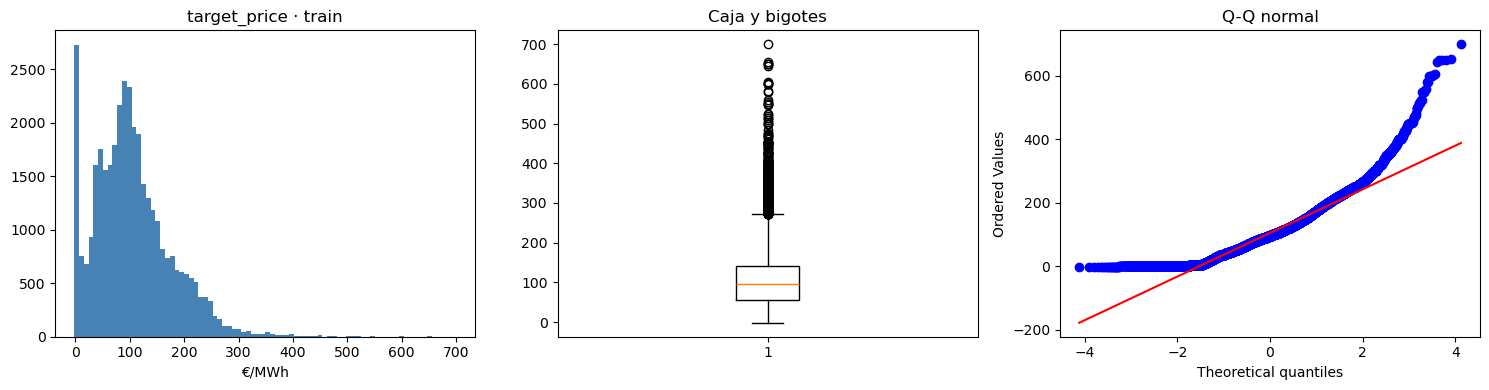

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(datos.loc[train, TARGET], bins=80, color="steelblue")
ax[0].set_title("target_price · train"); ax[0].set_xlabel("€/MWh")
ax[1].boxplot(datos.loc[train, TARGET].dropna(), vert=True)
ax[1].set_title("Caja y bigotes")
import scipy.stats as st
st.probplot(datos.loc[train, TARGET].dropna(), dist="norm", plot=ax[2])
ax[2].set_title("Q-Q normal")
plt.tight_layout()

In [14]:
registrar('3 · descriptivo', datos, [TARGET] + numericas + COLS_CATEGORICAS)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900
2,3 · descriptivo,50121,99,6290,5900


## 4 · Corrección de errores detectados

Tres bloques, y cada uno se lleva columnas por delante. La tabla de control al final
de la sección muestra cuántas.

### 4.1 · Columnas constantes o cuasi-constantes

Criterio de clase: una variable sin varianza no aporta nada a ningún modelo, y en los
lineales además rompe la inversión de la matriz. Se mira **sobre train**: una columna
puede tener dos valores en el fichero entero y uno solo en el periodo de entrenamiento,
y en ese caso el modelo tampoco puede aprender nada de ella.

In [15]:
distintos_train = datos.loc[train, numericas].nunique()
constantes = distintos_train[distintos_train <= 2].index.tolist()

if constantes:
    for c in constantes:
        print(f"  {c:34s} distintos={distintos_train[c]}  "
              f"valores={sorted(datos.loc[train, c].dropna().unique())[:4]}")
else:
    print("  Ninguna columna constante en train.")

print(f"\n{len(constantes)} columnas sin varianza -> fuera.")

  capdisp_fuel_mw                    distintos=1  valores=[np.float64(0.9937)]

1 columnas sin varianza -> fuera.


### 4.2 · Las seis columnas NTC de la variante `sin_2020`

Son las que distinguen esta variante de `sin_ntc_prev`, y las que le cuestan 304 días
de entrenamiento: su primer dato es el 2020-11-01, así que exigirlas recorta la ventana.

Se mide qué aportan antes de aceptar ese precio. Tres medidas porque discrepar es
informativo: Pearson (relación lineal), Spearman (monótona) y V de Cramer (asociación
sobre quintiles, que capta formas de U o escalón que las otras dan por nulas).

In [16]:
ntc = [c for c in numericas if "ntc" in c and c.endswith("_prev")]

if ntc:
    filas = []
    for c in ntc:
        par = datos.loc[train, [c, TARGET]].dropna()
        try:
            vc = Vcramer(par[c].reset_index(drop=True), par[TARGET].reset_index(drop=True))
        except Exception:
            vc = np.nan
        filas.append({
            "variable": c,
            "distintos": datos.loc[train, c].nunique(),
            "pearson": par[c].corr(par[TARGET]),
            "spearman": par[c].corr(par[TARGET], method="spearman"),
            "v_cramer": vc,
        })
    tabla_ntc = pd.DataFrame(filas).sort_values("v_cramer", ascending=False)
    display(tabla_ntc.round(3))

    # Referencia: qué es "tener señal" en este dataset.
    print("\nPara comparar, las dos mejores variables del fichero:")
    for c in ["es_esios_D", "gas_mibgas"]:
        par = datos.loc[train, [c, TARGET]].dropna()
        vc = Vcramer(par[c].reset_index(drop=True), par[TARGET].reset_index(drop=True))
        print(f"  {c:14s} pearson={par[c].corr(par[TARGET]):+.3f}  v_cramer={vc:.3f}")
else:
    tabla_ntc = pd.DataFrame()
    print("La variante elegida no trae columnas NTC.")

,variable,distintos,pearson,spearman,v_cramer
3,ree_ntc_exppt_prev,829,0.261,0.290,0.164
0,ree_ntc_impfr_prev,183,-0.097,-0.116,0.090
1,ree_ntc_expfr_prev,346,-0.097,-0.133,0.085
2,ree_ntc_imppt_prev,1259,0.014,-0.031,0.078
4,ree_ntc_impma_prev,3,0.111,0.104,NaN
5,ree_ntc_expma_prev,5,0.088,0.091,NaN



Para comparar, las dos mejores variables del fichero:
  es_esios_D     pearson=+0.903  v_cramer=0.620
  gas_mibgas     pearson=+0.679  v_cramer=0.409


In [17]:
# Se descartan las que no llegan a V de Cramer 0,10 o son cuasi-constantes.
# `ree_ntc_exppt_prev` sobrevive por poco -- se revisa en la sección 9 por redundancia.
UMBRAL_VCRAMER = 0.10

if len(tabla_ntc):
    ntc_fuera = tabla_ntc[(tabla_ntc["v_cramer"].isna()) |
                          (tabla_ntc["v_cramer"] < UMBRAL_VCRAMER)]["variable"].tolist()
    for c in ntc_fuera:
        print(f"  fuera: {c}")
    print(f"\nSe mantienen: {[c for c in ntc if c not in ntc_fuera]}")
else:
    ntc_fuera = []

  fuera: ree_ntc_impfr_prev
  fuera: ree_ntc_expfr_prev
  fuera: ree_ntc_imppt_prev
  fuera: ree_ntc_impma_prev
  fuera: ree_ntc_expma_prev

Se mantienen: ['ree_ntc_exppt_prev']


### 4.3 · Redundancia exacta por construcción

`ree_grenov_prev` es la suma de `ree_gwind_prev` + `ree_gsolar_prev`. El constructor v5
lo documenta y lo deja a propósito, para que decida el modelo. En una depuración eso no
se sostiene: es colinealidad perfecta, y en un modelo lineal la matriz no invierte.

Se comprueba en vez de darlo por supuesto.

In [18]:
suma = datos["ree_gwind_prev"] + datos["ree_gsolar_prev"]
dif = (datos["ree_grenov_prev"] - suma).abs()
print(f"ree_grenov_prev vs (wind + solar):")
print(f"  diferencia máxima : {dif.max():.6f}")
print(f"  filas idénticas   : {(dif < 1e-6).sum():,} de {len(datos):,}")

if dif.max() < 1e-6:
    redundantes_exactas = ["ree_grenov_prev"]
    print("\n  Colinealidad exacta confirmada -> se descarta ree_grenov_prev,")
    print("  se conservan los dos sumandos (más informativos por separado).")
else:
    redundantes_exactas = []
    print("\n  No es una suma exacta -> se conserva.")

ree_grenov_prev vs (wind + solar):
  diferencia máxima : 0.000000
  filas idénticas   : 50,121 de 50,121

  Colinealidad exacta confirmada -> se descarta ree_grenov_prev,
  se conservan los dos sumandos (más informativos por separado).


In [19]:
descartes_s4 = sorted(set(constantes) | set(ntc_fuera) | set(redundantes_exactas))
numericas = [c for c in numericas if c not in descartes_s4]

print(f"Descartadas en la sección 4: {len(descartes_s4)}")
for c in descartes_s4:
    motivo = ("constante" if c in constantes
              else "NTC sin señal" if c in ntc_fuera
              else "colinealidad exacta")
    print(f"  {c:26s} {motivo}")
print(f"\nNuméricas restantes: {len(numericas)}")

registrar("4 · corrección de errores", datos, [TARGET] + numericas + COLS_CATEGORICAS)

Descartadas en la sección 4: 7
  capdisp_fuel_mw            constante
  ree_grenov_prev            colinealidad exacta
  ree_ntc_expfr_prev         NTC sin señal
  ree_ntc_expma_prev         NTC sin señal
  ree_ntc_impfr_prev         NTC sin señal
  ree_ntc_impma_prev         NTC sin señal
  ree_ntc_imppt_prev         NTC sin señal

Numéricas restantes: 83


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900
2,3 · descriptivo,50121,99,6290,5900
3,4 · corrección de errores,50121,92,6290,5900


## 5 · Separación de objetivo e inputs

En la tarea de clase esto separaba dos variables objetivo (una binaria y una continua).
Aquí hay una sola, pero sí hay un grupo que conviene apartar sin descartarlo: los
**precios de otras zonas** (`fr_entsoe_D`, `de_lu_entsoe_D`…). Son mercados acoplados y
correlacionan altísimo con el objetivo; mezclarlos con el resto haría que el ranking de
la sección 10 solo hablara de ellos.

In [20]:
precios_zona = [c for c in numericas if c.endswith("_D") or c.startswith("spread_")]
variables_input = [c for c in numericas if c not in precios_zona]

var_objetivo = datos[TARGET]

print(f"Objetivo                    : {TARGET}")
print(f"Precios de zona (apartados) : {len(precios_zona)}")
print(f"  {precios_zona}")
print(f"Pool de candidatas          : {len(variables_input)}")
print(f"Categóricas de calendario   : {len(COLS_CATEGORICAS)}")

# Particiona, no descarta: la tabla de control no debe moverse aquí.
registrar("5 · separación objetivo/inputs", datos, [TARGET] + numericas + COLS_CATEGORICAS)

Objetivo                    : target_price
Precios de zona (apartados) : 14
  ['es_esios_D', 'pt_entsoe_D', 'fr_entsoe_D', 'de_lu_entsoe_D', 'it_nord_entsoe_D', 'ch_entsoe_D', 'be_entsoe_D', 'nl_entsoe_D', 'at_entsoe_D', 'pl_entsoe_D', 'cz_entsoe_D', 'spread_es_pt_D', 'spread_es_fr_D', 'spread_es_de_D']
Pool de candidatas          : 69
Categóricas de calendario   : 8


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900
2,3 · descriptivo,50121,99,6290,5900
3,4 · corrección de errores,50121,92,6290,5900
4,5 · separación objetivo/inputs,50121,92,6290,5900


## 6 · Análisis de valores atípicos

Criterio de clase (`atipicosAmissing`): un valor es atípico solo si cumple **a la vez**

- `|z| > 3` si la variable es simétrica, o `|MAD-score| > 8` si es asimétrica, **y**
- queda fuera de `Q1 − 3·IQR` / `Q3 + 3·IQR`.

Es más conservador que Tukey (1,5·IQR), y aun así **aquí no se aplica el tratamiento de
clase**. En la tarea de elecciones los atípicos se pasaban a *missing* y se imputaban.
En una serie de precio eléctrico eso destruiría el fenómeno: una hora a 300 €/MWh en una
ola de calor sin viento es exactamente lo que hay que predecir, y sustituirla por la
mediana enseña al modelo que ese día fue normal.

El criterio se usa para **ordenar variables por rareza** y decidir caso a caso.

In [21]:
atipicos = dep.diagnostico_atipicos(datos[train], variables_input + [TARGET])
atipicos[atipicos["n_atipicos"] > 0].head(20)

,variable,n_atipicos,pct_atipicos,asimetria,minimo
0,gas_ttf_m1,312,0.854443,1.862135,12.9500
1,gas_mibgas,240,0.657264,1.663383,13.1400
2,msl_mean_met_Dm1,16,0.043818,0.046562,99126.5469
3,msl_mean_met_Dm2,16,0.043818,0.049186,99126.5469
4,target_price,6,0.016432,1.052999,-2.0000


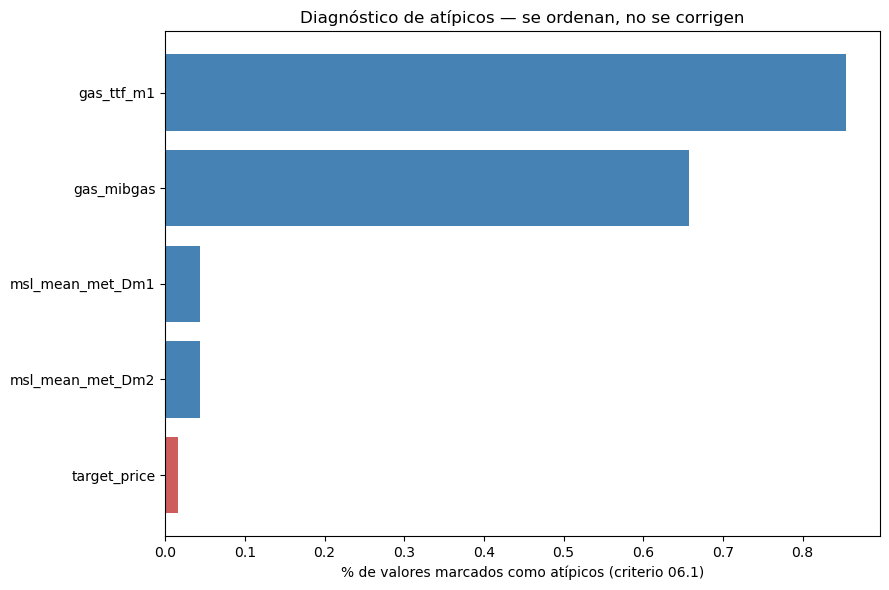

In [22]:
top = atipicos[atipicos["n_atipicos"] > 0].head(18).iloc[::-1]
if len(top):
    plt.figure(figsize=(9, 6))
    colores = ["indianred" if v == TARGET else "steelblue" for v in top["variable"]]
    plt.barh(top["variable"], top["pct_atipicos"], color=colores)
    plt.xlabel("% de valores marcados como atípicos (criterio 06.1)")
    plt.title("Diagnóstico de atípicos — se ordenan, no se corrigen")
    plt.tight_layout()

In [23]:
n_obj = int(atipicos.loc[atipicos["variable"] == TARGET, "n_atipicos"].iloc[0])
print(f"El propio objetivo tiene {n_obj} horas marcadas como atípicas "
      f"({n_obj / train.sum() * 100:.3f}% de train).")
print("Se conservan: son los picos de precio, el caso que más importa acertar.\n")

extremos = datos[train].nlargest(8, TARGET)[["fecha_objetivo", "hora", TARGET,
                                             "gas_mibgas", "ree_gwind_prev", "ree_demanda_prev"]]
print("Las 8 horas más caras de train:")
print(extremos.to_string(index=False))

El propio objetivo tiene 6 horas marcadas como atípicas (0.016% de train).
Se conservan: son los picos de precio, el caso que más importa acertar.

Las 8 horas más caras de train:
fecha_objetivo  hora  target_price  gas_mibgas  ree_gwind_prev  ree_demanda_prev
    2022-03-08    19        700.00      181.54          3177.0           32250.0
    2022-03-08    20        654.91      181.54          3031.0           33620.0
    2022-03-08    18        651.00      181.54          3676.0           29895.0
    2022-03-08    21        651.00      181.54          3057.0           32646.0
    2022-03-08    22        650.00      181.54          3223.0           29911.0
    2022-03-08     8        645.00      181.54          8091.0           31080.0
    2022-03-09    19        605.00      213.60          8755.0           31809.0
    2022-03-08    17        603.08      181.54          4651.0           30298.0


In [24]:
registrar('6 · atípicos (sin cambios)', datos, [TARGET] + numericas + COLS_CATEGORICAS)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900
2,3 · descriptivo,50121,99,6290,5900
3,4 · corrección de errores,50121,92,6290,5900
4,5 · separación objetivo/inputs,50121,92,6290,5900
5,6 · atípicos (sin cambios),50121,92,6290,5900


## 7 · Análisis de valores perdidos

Aquí es donde este dataset tiene su único problema serio de calidad.

In [25]:
prop = datos[variables_input].isna().mean()
con_nulos = prop[prop > 0].sort_values(ascending=False)

print(f"Variables con algún perdido: {len(con_nulos)} de {len(variables_input)}")
print(f"Celdas nulas totales       : {datos[variables_input].isna().sum().sum():,} "
      f"({datos[variables_input].isna().mean().mean() * 100:.3f}% del pool)")
print()
print((con_nulos.head(15) * 100).round(2).astype(str).add(" %").to_string())

Variables con algún perdido: 44 de 69
Celdas nulas totales       : 6,193 (0.179% del pool)

pdbc_pumping_cons_mw_mean_lag1d    11.3 %
pdbc_pumping_gen_mw_mean_lag1d     0.53 %
co2_eua_dec                        0.05 %
entsoe_load_Dm1                    0.01 %
pumping_cons_mw_Dm1                0.01 %
total_net_flow_mw_Dm1              0.01 %
gen_peninsular_mw_Dm1              0.01 %
wind_mw_Dm1                        0.01 %
biomass_mw_Dm1                     0.01 %
ree_netflow_fr_Dm1                 0.01 %
ree_netflow_pt_Dm1                 0.01 %
ree_netflow_ma_Dm1                 0.01 %
tcc_mean_met_Dm1                   0.01 %
waste_mw_Dm1                       0.01 %
hydro_run_river_mw_Dm1             0.01 %


### Hallazgo 7.1 — `pdbc_pumping_cons_mw_mean_lag1d` concentra casi todo

No es un goteo repartido: son **días completos** sin dato en la fuente PDBC, y se
acumulan en 2021. Conviene comprobar si el nulo significa "no hubo bombeo" (cero
estructural, se rellena con 0) o "no se publicó el dato" (hueco real).

In [26]:
col_pc = "pdbc_pumping_cons_mw_mean_lag1d"
anio = datos["fecha_objetivo"].dt.year

print("Nulos por año (%):")
print(datos.groupby(anio)[col_pc].apply(lambda s: s.isna().mean() * 100).round(1).to_string())

nn = datos[datos[col_pc].isna()]
print(f"\nDías afectados: {nn['fecha_objetivo'].dt.date.nunique()}")
print(f"Horas nulas por día afectado: {nn.groupby(nn['fecha_objetivo'].dt.date).size().value_counts().to_dict()}")
print(f"\nDistribución de los valores presentes:")
print(datos[col_pc].describe().round(2).to_string())
print(f"Ceros exactos: {(datos[col_pc] == 0).sum()}")

Nulos por año (%):
fecha_objetivo
2020    11.5
2021    38.6
2022    10.1
2023     9.9
2024     1.9
2025     1.4
2026     1.4

Días afectados: 236
Horas nulas por día afectado: {24: 236}

Distribución de los valores presentes:
count    44457.00
mean     -1331.19
std        901.46
min      -3795.36
25%      -1971.84
50%      -1251.17
75%       -565.98
max         -1.00
Ceros exactos: 0


In [27]:
print("LECTURA: la variable es siempre negativa (es consumo) y NUNCA vale 0. Si el nulo")
print("fuese 'no hubo bombeo', aparecerían ceros; no hay ninguno. Y los huecos son días")
print("enteros de 24 horas, no horas sueltas.")
print()
print("  -> Son huecos reales de publicación de PDBC, no ceros estructurales.")
print("  -> Rellenar con 0 inventaría los días sin bombeo que sí lo tuvieron.")
print("  -> Como el valor es una MEDIA DIARIA (constante dentro del día), la")
print("     interpolación correcta es entre días, no entre horas.")

LECTURA: la variable es siempre negativa (es consumo) y NUNCA vale 0. Si el nulo
fuese 'no hubo bombeo', aparecerían ceros; no hay ninguno. Y los huecos son días
enteros de 24 horas, no horas sueltas.

  -> Son huecos reales de publicación de PDBC, no ceros estructurales.
  -> Rellenar con 0 inventaría los días sin bombeo que sí lo tuvieron.
  -> Como el valor es una MEDIA DIARIA (constante dentro del día), la
     interpolación correcta es entre días, no entre horas.


### Patrón de perdidos

La matriz de correlación de ausencias responde a una pregunta concreta: ¿faltan las
mismas filas en varias columnas a la vez? Si sí, hay una fuente caída, no ruido
independiente, y conviene tratarlas en bloque.

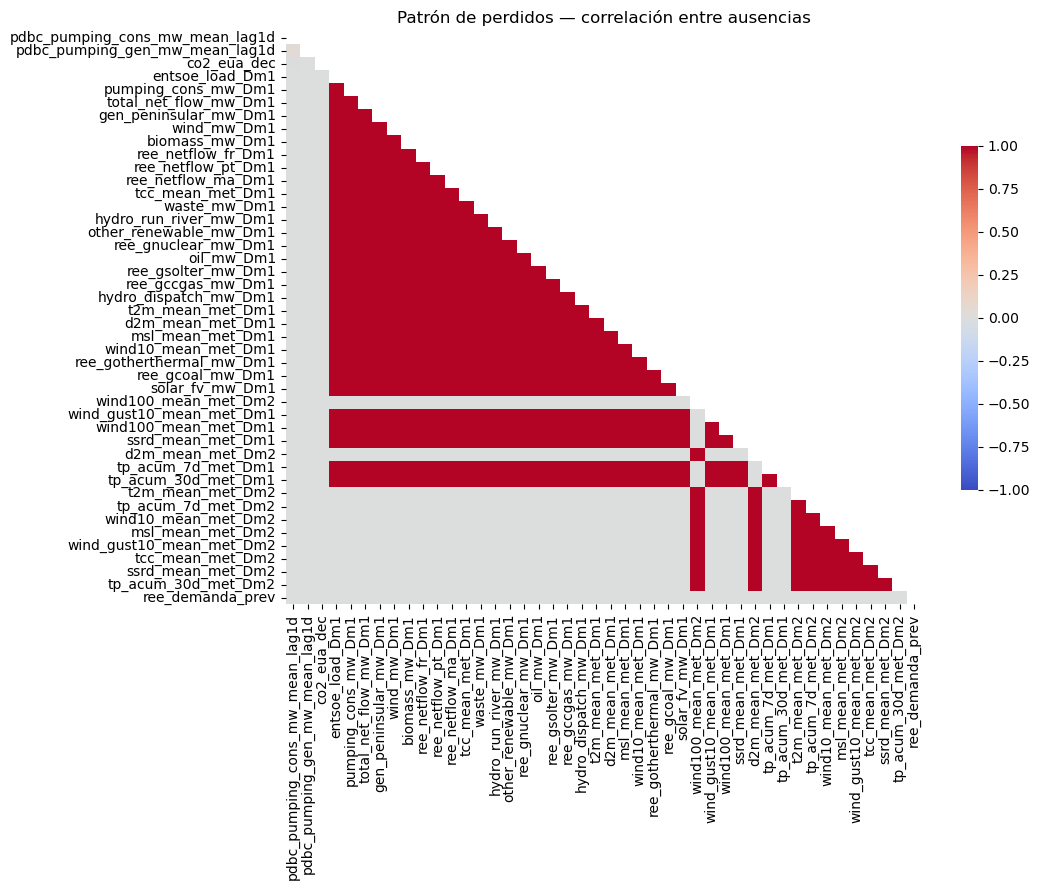

In [28]:
cols_na = list(con_nulos.index)
if len(cols_na) > 1:
    corr_na = datos[cols_na].isna().corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_na, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                mask=np.triu(np.ones_like(corr_na, dtype=bool)),
                cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
    plt.title("Patrón de perdidos — correlación entre ausencias")
    plt.tight_layout()

In [29]:
# prop_missings por observación, como en la sección 7 de la tarea de clase.
datos["prop_missings"] = datos[variables_input].isna().mean(axis=1)
print(datos["prop_missings"].describe().to_string())

n_malas = int((datos["prop_missings"] > 0.5).sum())
print(f"\nFilas con >50% de campos perdidos: {n_malas}")
print()
print("En la tarea de clase esas filas se eliminaban. Aquí NO: borrar una fila rompe")
print("la continuidad del eje temporal y descuadra los días de 24 horas que el modelo")
print("Seq2Seq espera. Se marca la proporción y se sigue.")

count    50121.000000
mean         0.001791
std          0.006891
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.434783

Filas con >50% de campos perdidos: 0

En la tarea de clase esas filas se eliminaban. Aquí NO: borrar una fila rompe
la continuidad del eje temporal y descuadra los días de 24 horas que el modelo
Seq2Seq espera. Se marca la proporción y se sigue.


In [30]:
registrar('7 · perdidos (marcados)', datos, [TARGET] + numericas + COLS_CATEGORICAS)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900
2,3 · descriptivo,50121,99,6290,5900
3,4 · corrección de errores,50121,92,6290,5900
4,5 · separación objetivo/inputs,50121,92,6290,5900
5,6 · atípicos (sin cambios),50121,92,6290,5900
6,7 · perdidos (marcados),50121,92,6290,5900


## 8 · Imputación

Dos tratamientos según la naturaleza del hueco, en lugar de la mediana global de clase:

1. **Variables horarias** (meteo, commodities, precios): interpolación temporal acotada
   a 3 horas. Respeta la forma local; un hueco mayor se deja en `NaN`, declarado.
2. **`pdbc_pumping_cons_mw_mean_lag1d`**: interpolación **entre días**, porque el valor
   es una media diaria constante dentro del día. Acotada a 3 días.

La mediana global se descarta por lo obvio: la mediana de la demanda peninsular es un
valor de las siete de la tarde, y plantarlo a las cuatro de la mañana crea un dato que
contradice todo lo que lo rodea.

In [31]:
# --- 8.1 Interpolación horaria del resto de columnas -----------------------
otras = [c for c in variables_input + precios_zona if c != col_pc]
datos, informe_imput = dep.imputacion_temporal(
    datos.rename(columns={"ts": "ts_utc"}), otras, limite=3
)
datos = datos.rename(columns={"ts_utc": "ts"})
informe_imput.head(15)

,nulos_antes,nulos_despues,imputados
pdbc_pumping_gen_mw_mean_lag1d,264,210,54
spread_es_fr_D,7,0,7
spread_es_pt_D,7,0,7
at_entsoe_D,7,0,7
pl_entsoe_D,7,0,7
nl_entsoe_D,7,0,7
spread_es_de_D,7,0,7
be_entsoe_D,7,0,7
fr_entsoe_D,7,0,7
it_nord_entsoe_D,7,0,7


In [32]:
# --- 8.2 Interpolación diaria del bombeo -----------------------------------
antes = datos[col_pc].isna().sum()

diario = datos.groupby("fecha_objetivo")[col_pc].first()
diario_int = diario.interpolate(method="time", limit=3, limit_area="inside")
datos[col_pc] = datos["fecha_objetivo"].map(diario_int)

despues = datos[col_pc].isna().sum()
print(f"{col_pc}")
print(f"  nulos antes   : {antes:,}  ({antes / len(datos) * 100:.1f}%)")
print(f"  nulos después : {despues:,}  ({despues / len(datos) * 100:.1f}%)")
print(f"  imputados     : {antes - despues:,}  ({(antes - despues) / 24:.0f} días)")
print(f"\n  Los {despues / 24:.0f} días restantes son huecos de más de 3 días seguidos:")
print("  no se inventan.")

pdbc_pumping_cons_mw_mean_lag1d
  nulos antes   : 5,664  (11.3%)
  nulos después : 984  (2.0%)
  imputados     : 4,680  (195 días)

  Los 41 días restantes son huecos de más de 3 días seguidos:
  no se inventan.


In [33]:
restantes = datos[variables_input].isna().sum()
restantes = restantes[restantes > 0].sort_values(ascending=False)
print(f"Celdas perdidas restantes: {datos[variables_input].isna().sum().sum():,}")
if len(restantes):
    print("\nDónde quedan:")
    print(restantes.to_string())
else:
    print("Ninguna.")

registrar("8 · imputación", datos, [TARGET] + numericas + COLS_CATEGORICAS)

Celdas perdidas restantes: 1,212

Dónde quedan:
pdbc_pumping_cons_mw_mean_lag1d    984
pdbc_pumping_gen_mw_mean_lag1d     210
co2_eua_dec                         18


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga,50121,103,6290,5900
1,2 · tipado,50121,99,6290,5900
2,3 · descriptivo,50121,99,6290,5900
3,4 · corrección de errores,50121,92,6290,5900
4,5 · separación objetivo/inputs,50121,92,6290,5900
5,6 · atípicos (sin cambios),50121,92,6290,5900
6,7 · perdidos (marcados),50121,92,6290,5900
7,8 · imputación,50121,92,1212,1188


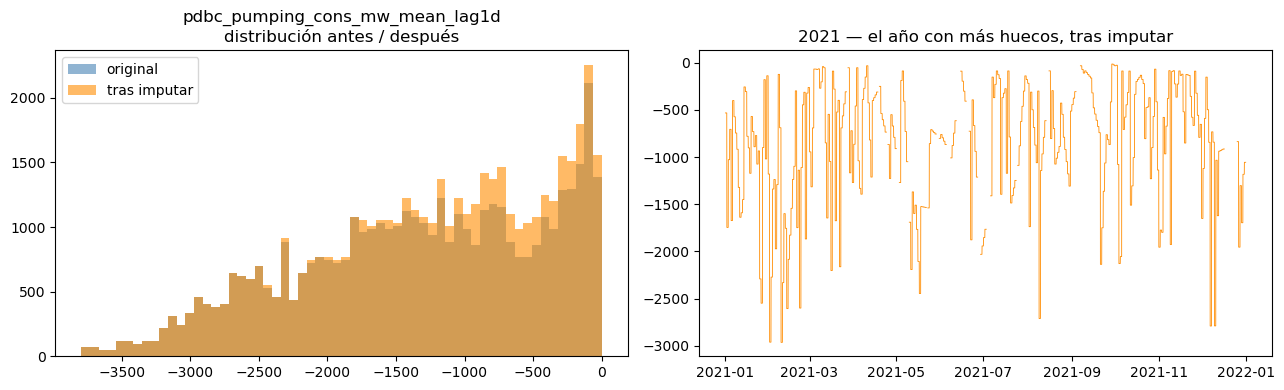

In [34]:
# Control visual: la imputación no debe cambiar la forma de la distribución.
crudo = pd.read_csv(ORIGEN, usecols=[col_pc])[col_pc]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(crudo.dropna(), bins=60, alpha=0.6, label="original", color="steelblue")
ax[0].hist(datos[col_pc].dropna(), bins=60, alpha=0.6, label="tras imputar", color="darkorange")
ax[0].legend(); ax[0].set_title(f"{col_pc}\ndistribución antes / después")
sub = datos[datos["fecha_objetivo"].dt.year == 2021]
ax[1].plot(sub["ts"], sub[col_pc], lw=0.6, color="darkorange")
ax[1].set_title("2021 — el año con más huecos, tras imputar")
plt.tight_layout()

## 9 · Redundancia entre candidatas

Cada par muy correlacionado es una decisión pendiente. No se resuelve sola: la respuesta
depende de la fuente (cuál se publica antes, cuál tiene menos revisiones), no del
coeficiente. Aquí se listan para que la elección sea explícita.

In [35]:
redundancia = dep.bloques_correlacion(datos[train], variables_input, umbral=0.95)
print(f"Pares con |r| >= 0.95: {len(redundancia)}")
redundancia.round(4)

Pares con |r| >= 0.95: 11


,var_a,var_b,correlacion
0,tp_acum_30d_met_Dm1,tp_acum_30d_met_Dm2,0.9947
1,ssrd_mean_met_Dm1,ssrd_mean_met_Dm2,0.9921
2,t2m_mean_met_Dm1,t2m_mean_met_Dm2,0.9800
3,wind10_mean_met_Dm2,wind_gust10_mean_met_Dm2,0.9737
4,wind10_mean_met_Dm1,wind_gust10_mean_met_Dm1,0.9737
5,wind10_mean_met_Dm2,wind100_mean_met_Dm2,0.9736
6,wind10_mean_met_Dm1,wind100_mean_met_Dm1,0.9736
7,tp_acum_7d_met_Dm1,tp_acum_7d_met_Dm2,0.9611
8,ree_gsolar_prev,solar_fv_mw_Dm1,0.9580
9,d1_month_cos,d1_doy_cos,0.9572


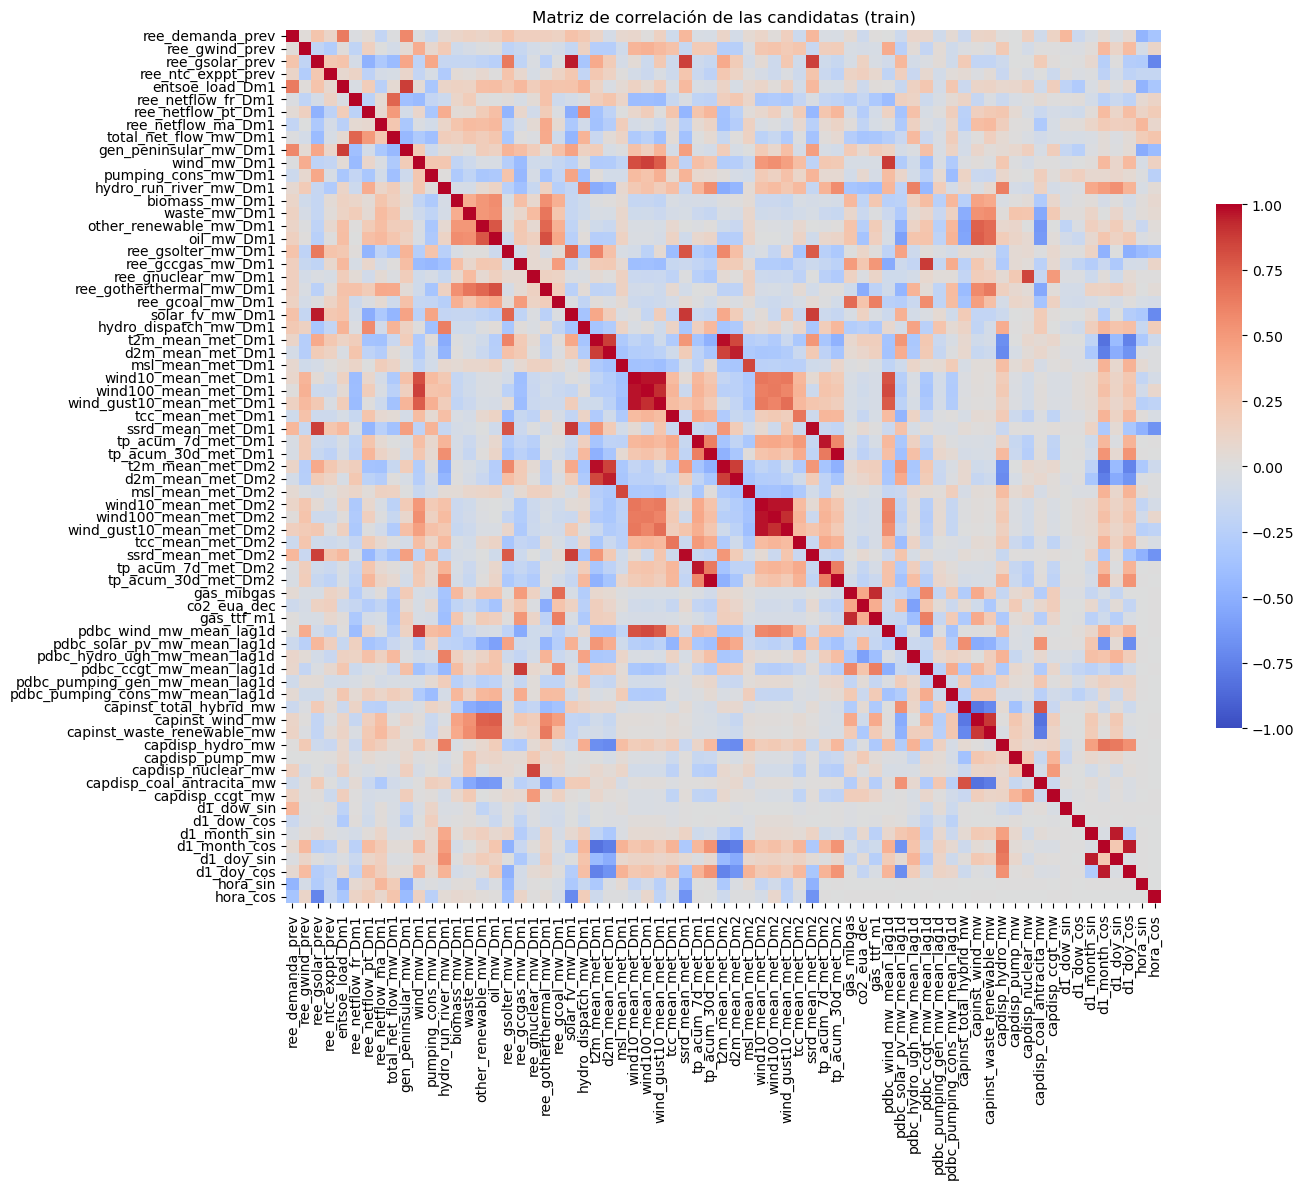

In [36]:
cols_corr = [c for c in variables_input if datos.loc[train, c].notna().mean() > 0.9]
plt.figure(figsize=(14, 12))
sns.heatmap(datos.loc[train, cols_corr].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
plt.title("Matriz de correlación de las candidatas (train)")
plt.tight_layout()

## 10 · Importancia de variables frente al objetivo

El gráfico de V de Cramer de la sección 7.2 de la tarea de clase, aplicado aquí.

**Aviso de lectura**: esto mide asociación, no capacidad predictiva incremental. Una
variable puede tener V de Cramer alto y no aportar nada al modelo si otra ya lleva esa
información — por eso se lee junto a la sección 9, no en su lugar.

In [37]:
ranking = dep.ranking_asociacion(datos[train], variables_input, TARGET)
ranking.head(25).round(3)

,variable,pearson,spearman,v_cramer,n_pares,abs_pearson
0,gas_mibgas,0.679,0.716,0.409,36515,0.679
1,gas_ttf_m1,0.569,0.692,0.401,36515,0.569
2,capinst_waste_renewable_mw,0.213,0.221,0.375,36515,0.213
3,ree_gotherthermal_mw_Dm1,0.225,0.186,0.299,36515,0.225
4,ree_gcoal_mw_Dm1,0.542,0.547,0.297,36515,0.542
5,ree_gccgas_mw_Dm1,0.458,0.546,0.292,36515,0.458
6,capinst_wind_mw,0.386,0.393,0.279,36515,0.386
7,pdbc_ccgt_mw_mean_lag1d,0.426,0.538,0.275,36515,0.426
8,capdisp_coal_antracita_mw,-0.318,-0.267,0.255,36515,0.318
9,capinst_total_hybrid_mw,-0.290,-0.324,0.251,36515,0.290


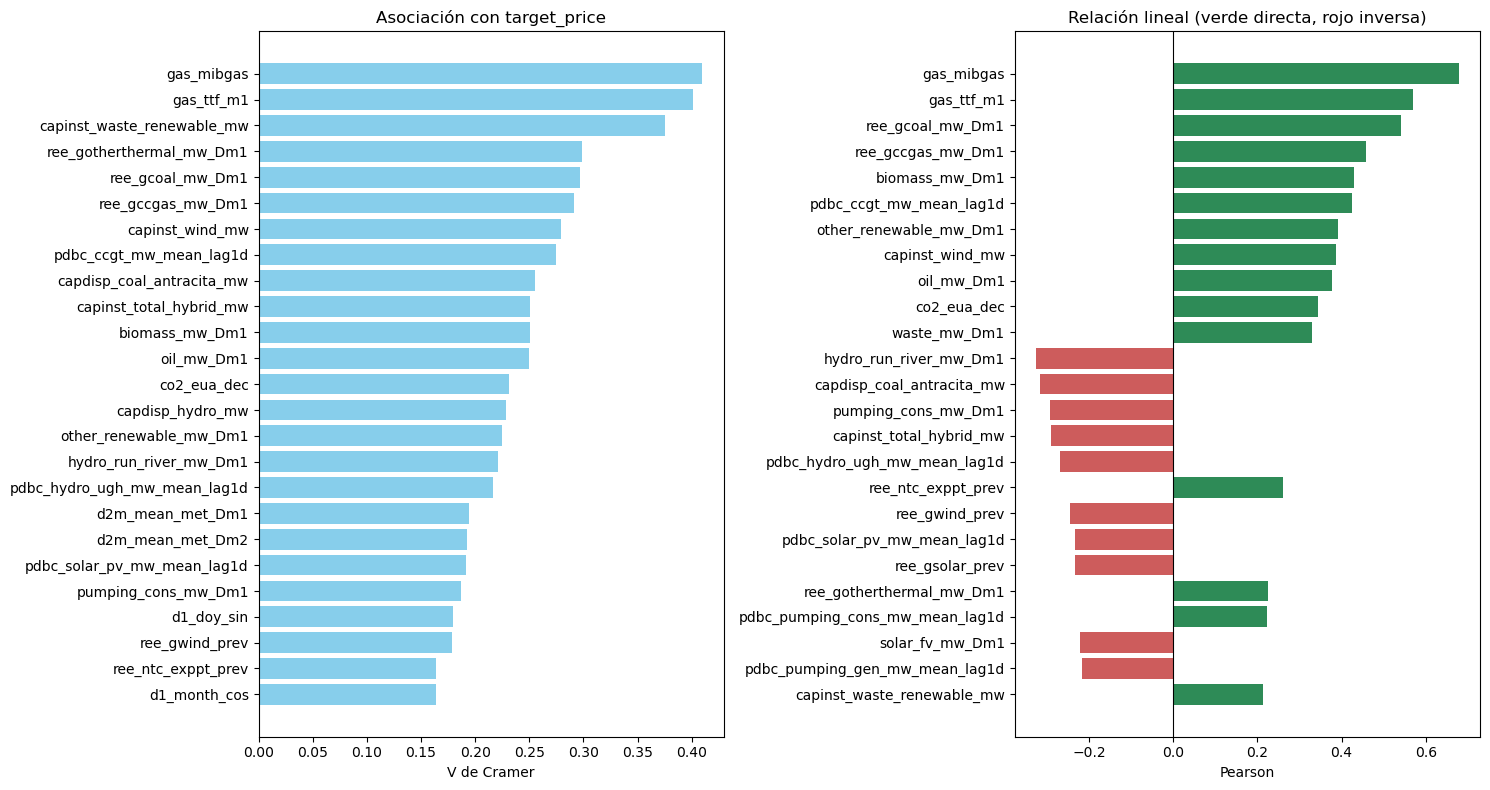

In [38]:
top = ranking.dropna(subset=["v_cramer"]).head(25).iloc[::-1]
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].barh(top["variable"], top["v_cramer"], color="skyblue")
ax[0].set_xlabel("V de Cramer"); ax[0].set_title("Asociación con target_price")
top_p = ranking.dropna(subset=["abs_pearson"]).sort_values("abs_pearson", ascending=False).head(25).iloc[::-1]
ax[1].barh(top_p["variable"], top_p["pearson"],
           color=["indianred" if v < 0 else "seagreen" for v in top_p["pearson"]])
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_xlabel("Pearson"); ax[1].set_title("Relación lineal (verde directa, rojo inversa)")
plt.tight_layout()

In [39]:
cola = ranking[(ranking["v_cramer"] < 0.05) & (ranking["abs_pearson"] < 0.05)]
print(f"Candidatas sin asociación apreciable: {len(cola)}")
if len(cola):
    print(cola[["variable", "pearson", "spearman", "v_cramer"]].round(3).to_string(index=False))
print()
print("No se descartan automáticamente. Una variable puede no correlacionar con el")
print("precio y sí ser útil en interacción (la meteorología es el caso claro: la")
print("temperatura sola dice poco, la temperatura en agosto dice mucho).")

Candidatas sin asociación apreciable: 2
  variable  pearson  spearman  v_cramer
d1_dow_cos   -0.028    -0.033     0.040
  hora_sin   -0.027    -0.015     0.037

No se descartan automáticamente. Una variable puede no correlacionar con el
precio y sí ser útil en interacción (la meteorología es el caso claro: la
temperatura sola dice poco, la temperatura en agosto dice mucho).


## 11 · Guardado y evolución completa

In [40]:
SALIDA = REPO / "data" / "bronze" / f"dataset_horario_{VARIANTE}_depurado.parquet"
SALIDA.parent.mkdir(parents=True, exist_ok=True)

cols_finales = (COLS_CONTROL + ["hora", TARGET] + variables_input
                + precios_zona + COLS_CATEGORICAS[1:] + ["prop_missings"])
cols_finales = list(dict.fromkeys(cols_finales))          # sin duplicados, orden estable
final = datos[cols_finales].copy()

final.to_parquet(SALIDA, index=False)
print(f"Guardado -> {SALIDA.relative_to(REPO)}")
print(f"           {final.shape[0]:,} filas x {final.shape[1]} columnas")

Guardado -> data\bronze\dataset_horario_sin_2020_depurado.parquet
           50,121 filas x 97 columnas


In [41]:
control = registrar("11 · fichero final", final)
control["celdas_nulas_dif"] = control["celdas_nulas"].diff().fillna(0).astype(int)
control["columnas_dif"] = control["columnas"].diff().fillna(0).astype(int)
control

,etapa,filas,columnas,celdas_nulas,filas_con_nulo,celdas_nulas_dif,columnas_dif
0,0 · carga,50121,103,6290,5900,0,0
1,2 · tipado,50121,99,6290,5900,0,-4
2,3 · descriptivo,50121,99,6290,5900,0,0
3,4 · corrección de errores,50121,92,6290,5900,0,-7
4,5 · separación objetivo/inputs,50121,92,6290,5900,0,0
5,6 · atípicos (sin cambios),50121,92,6290,5900,0,0
6,7 · perdidos (marcados),50121,92,6290,5900,0,0
7,8 · imputación,50121,92,1212,1188,-5078,0
8,11 · fichero final,50121,97,1212,1188,0,5


In [42]:
print("=" * 70)
print(f"RESUMEN DE LA DEPURACIÓN · variante {VARIANTE}")
print("=" * 70)
print(f"  Columnas de partida            : {pd.read_csv(ORIGEN, nrows=1).shape[1]}")
print(f"  - constantes                   : {len(constantes)}")
print(f"  - NTC sin señal                : {len(ntc_fuera)}")
print(f"  - colinealidad exacta          : {len(redundantes_exactas)}")
print(f"  = pool de candidatas           : {len(variables_input)}")
print(f"    + precios de zona (apartados): {len(precios_zona)}")
print(f"    + categóricas de calendario  : {len(COLS_CATEGORICAS)}")
print()
print(f"  Celdas imputadas               : "
      f"{historial[-3]['celdas_nulas'] - historial[-2]['celdas_nulas']:,}")
print(f"  Celdas nulas restantes         : {final[variables_input].isna().sum().sum():,}")
print(f"  Pares redundantes |r|>=0.95    : {len(redundancia)} (pendientes de arbitrar)")
print()
print("  Atípicos: diagnosticados, NO corregidos (decisión de la sección 6).")
print("  Filas   : ninguna eliminada (decisión de la sección 7).")

RESUMEN DE LA DEPURACIÓN · variante sin_2020
  Columnas de partida            : 102
  - constantes                   : 1
  - NTC sin señal                : 5
  - colinealidad exacta          : 1
  = pool de candidatas           : 69
    + precios de zona (apartados): 14
    + categóricas de calendario  : 8

  Celdas imputadas               : 5,078
  Celdas nulas restantes         : 1,212
  Pares redundantes |r|>=0.95    : 11 (pendientes de arbitrar)

  Atípicos: diagnosticados, NO corregidos (decisión de la sección 6).
  Filas   : ninguna eliminada (decisión de la sección 7).


## Qué queda abierto

1. **Los pares redundantes de la sección 9** — decisión de fuente, no estadística.
2. **`ree_ntc_exppt_prev`** — sobrevivió al filtro por poco (V de Cramer 0,16) y es en
   parte un proxy de eólica e hidráulica, que ya están. Si cae, esta variante queda con
   el mismo juego de columnas que `sin_ntc_prev` pero con la ventana de entrenamiento
   limpia, que era la conclusión de la comparativa entre datasets.
3. **Los días de bombeo que siguen sin dato** — o se acepta el `NaN`, o se retira la
   columna, o se carga el histórico de PDBC que falta.